# Apartado 7 · Concordancia entre anotadoras: el techo humano

**Qué pregunta responde.** Cuánto coinciden dos personas entrenadas que han visto la misma
imagen y seguido el mismo protocolo. Sin ese número, un Dice de 0.53 no se sabe si es bueno
o malo; con él se sabe cuántos puntos de Dice separan al modelo de lo que consiguen dos
humanos entre sí.

**El estadístico principal es A1 contra A2, sin pasar por el GT del autor**: es el único
número del trabajo que no depende de quien lo escribe.

**Nada se agrega entre estratos.** En los frames tardíos el surco está fragmentado, y ahí
el desacuerdo mide ambigüedad del protocolo y no falta de precisión.

**Qué hay que haber ejecutado antes**, todo en `surco`:

```
conda run -n surco python scripts/concordancia_seleccion.py
conda run -n surco python scripts/concordancia_anotadora.py --anotadora anotadora_1
conda run -n surco python scripts/concordancia_anotadora.py --anotadora anotadora_2
conda run -n surco python scripts/concordancia_entre_anotadoras.py
```

El último necesita además las candidatas que dejó F8, para tratar al modelo como un tercer
anotador. Las lee según lo que declare `config.MEJOR_CELDA`, así que con la mejor celda en
M4 son las del encadenado:
`salidas/proceso/candidatas/candidatas_m4_microsam_lm_vit_b_*.npz`. Las ROIs de las dos
anotadoras están versionadas en `anotaciones/`: son dato primario irrecuperable.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))  # los scripts agregan; el notebook solo muestra

from surco import config, figuras, metricas
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# proceso/concordancia_anotadora_{1,2}.csv <- scripts/concordancia_anotadora.py
# proceso/concordancia_a1_a2.csv           <- scripts/concordancia_entre_anotadoras.py
# proceso/concordancia_tres_vias.csv       <- idem, anclado en cada lesion del GT
# proceso/concordancia_tercer_anotador.csv <- idem, el modelo como una anotadora mas
a1 = pd.read_csv(config.DIR_PROCESO / "concordancia_anotadora_1.csv")
a2 = pd.read_csv(config.DIR_PROCESO / "concordancia_anotadora_2.csv")
directo = pd.read_csv(config.DIR_PROCESO / "concordancia_a1_a2.csv")
tres = pd.read_csv(config.DIR_PROCESO / "concordancia_tres_vias.csv")
tercero = pd.read_csv(config.DIR_PROCESO / "concordancia_tercer_anotador.csv")

In [2]:
# Cada anotadora contra el GT, por estrato. Tres cosas distintas y separadas:
# trazado (solo donde las dos encontraron la lesion), falsos negativos humanos
# y ROIs sin pareja. Un Dice bajo y una lesion no vista no son el mismo problema.
for nombre, tabla in (("anotadora 1", a1), ("anotadora 2", a2)):
    encontradas = tabla[tabla["encontrada"]]
    print(nombre)
    for estrato, grupo in encontradas.groupby("estrato"):
        print(f"  {estrato:<9} n={len(grupo):2d}  Dice medio {grupo['dice'].mean():.4f}"
              f"  mediana {grupo['dice'].median():.4f}")
    print(f"  falsos negativos: {int((~tabla['encontrada']).sum())}"
          f"   ROIs sin pareja: {int(tabla.groupby('fichero')['sobrantes_en_el_fichero'].first().sum())}")

anotadora 1
  tardio    n=17  Dice medio 0.6792  mediana 0.6727
  temprano  n=16  Dice medio 0.7646  mediana 0.7697
  falsos negativos: 0   ROIs sin pareja: 0
anotadora 2
  tardio    n=16  Dice medio 0.5990  mediana 0.6267
  temprano  n=15  Dice medio 0.7142  mediana 0.7515
  falsos negativos: 3   ROIs sin pareja: 4


In [3]:
# EL TECHO HUMANO: A1 contra A2, emparejando por solape y sin GT de por medio.
# Sale de `tres`, que son las dos imagenes por unidad que fija el diseno. `directo`
# trae ademas las lesiones que comparten imagen con una unidad muestreada, asi que
# seis unidades aparecen alli tres veces: promediar sus 37 pares en plano las pesa
# de mas, contra la regla del apartado 6.3, y daba 0.5664 y 0.4604.
print("A1 contra A2, sin pasar por el GT")
print(tres.groupby("estrato")["a1_a2"].agg(["count", "mean", "median", "min", "max"]).to_string(float_format=lambda v: f"{v:7.4f}"))

# Los mismos 37 pares agregados por unidad antes de promediar: el mismo techo.
por_unidad = directo.groupby(["serie", "roi_a1", "estrato"])["dice_a1_a2"].mean()
print("\nCon los seis pares de mas, agregados por unidad")
print(por_unidad.groupby("estrato").agg(["count", "mean"]).to_string(float_format=lambda v: f"{v:7.4f}"))

# Las tres comparaciones sobre la misma lesion: quien es el atipico.
print("\nLas tres sobre las 31 lesiones que las dos encontraron")
print(tres.groupby("estrato")[["a1_gt", "a2_gt", "a1_a2"]].mean().to_string(float_format=lambda v: f"{v:7.4f}"))
print("\nLas dos concuerdan MENOS entre si que cualquiera con el GT: el GT queda")
print("entre las dos anotaciones, o sea que se desvian en direcciones opuestas.")

A1 contra A2, sin pasar por el GT
          count    mean  median     min     max
estrato                                        
tardio       16  0.5058  0.5235  0.0989  0.8813
temprano     15  0.5894  0.5910  0.1996  0.7995

Con los seis pares de mas, agregados por unidad
          count    mean
estrato                
tardio       16  0.5057
temprano     15  0.5871

Las tres sobre las 31 lesiones que las dos encontraron
           a1_gt   a2_gt   a1_a2
estrato                         
tardio    0.6870  0.5990  0.5058
temprano  0.7565  0.7142  0.5894

Las dos concuerdan MENOS entre si que cualquiera con el GT: el GT queda
entre las dos anotaciones, o sea que se desvian en direcciones opuestas.


           a1_a2  modelo_a1  modelo_a2
estrato                               
tardio    0.5058     0.5410     0.3669
temprano  0.5894     0.5585     0.4853


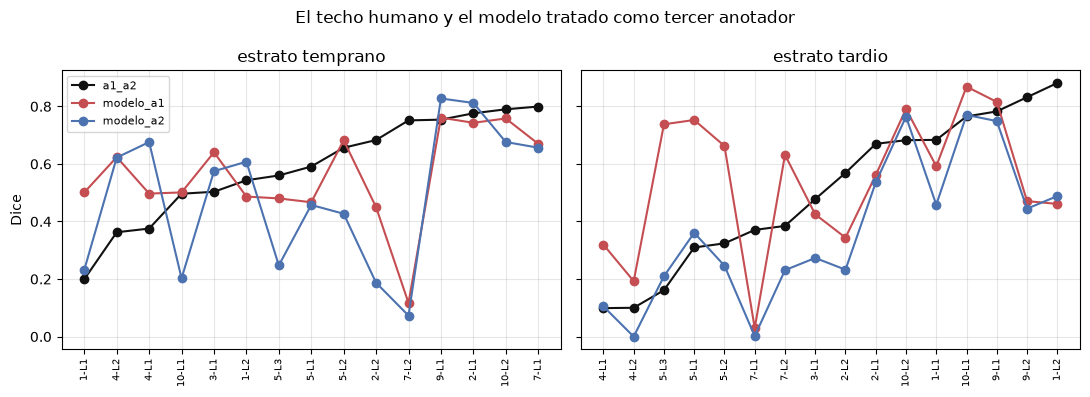

In [4]:
# El modelo como un tercer anotador, con el mismo emparejamiento por solape.
# Es la unica comparacion limpia: poner dice-contra-GT al lado de A1-contra-A2
# seria darle al modelo la ventaja de jugar en casa.
print(tercero.groupby("estrato")[["a1_a2", "modelo_a1", "modelo_a2"]].mean().to_string(float_format=lambda v: f"{v:7.4f}"))

figura, ejes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for plano, estrato in zip(ejes, ("temprano", "tardio")):
    grupo = tercero[tercero["estrato"] == estrato].sort_values("a1_a2")
    for columna, color in (("a1_a2", "#111111"), ("modelo_a1", "#c44e52"), ("modelo_a2", "#4c72b0")):
        plano.plot(grupo["unidad"], grupo[columna], marker="o", label=columna, color=color)
    plano.set_title(f"estrato {estrato}")
    plano.tick_params(axis="x", rotation=90, labelsize=7)
    plano.grid(alpha=0.3)
ejes[0].set_ylabel("Dice")
ejes[0].legend(fontsize=8)
figura.suptitle("El techo humano y el modelo tratado como tercer anotador")
figura.tight_layout()
figuras.guardar(figura, "figura_a7_tercer_anotador.png")

           count    mean
n_comp_c8               
1             24  0.5959
2              2  0.6026
3              2  0.5341
4              1  0.1613
5              1  0.1001
7              1  0.0989


  correlacion spearman : -0.370
  correlacion pearson  : -0.580


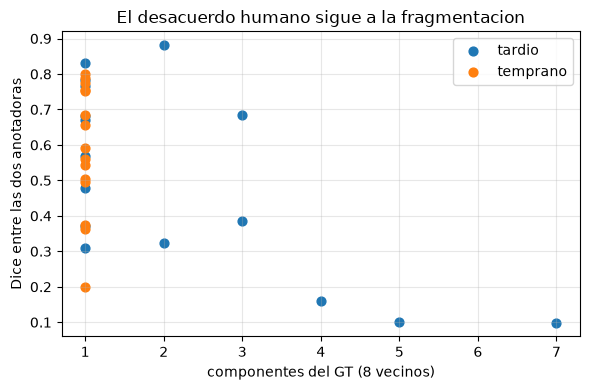

In [5]:
# El acuerdo cae con la fragmentacion del GT, y ahora sin el autor de por medio.
# salidas/inventario_gt.csv <- notebooks/F1_inventario.ipynb
inventario = pd.read_csv(config.DIR_PROCESO / "inventario_gt.csv")
junto = tres.merge(inventario[["serie", "etiqueta", "frame", config.COLUMNA_FRAGMENTACION]],
                   on=["serie", "etiqueta", "frame"], how="left")
print(junto.groupby(config.COLUMNA_FRAGMENTACION)["a1_a2"].agg(["count", "mean"]).to_string(float_format=lambda v: f"{v:7.4f}"))
for metodo in ("spearman", "pearson"):
    print(f"  correlacion {metodo:<9}: {junto['a1_a2'].corr(junto[config.COLUMNA_FRAGMENTACION], method=metodo):+.3f}")

figura, ejes = plt.subplots(figsize=(6, 4))
for estrato, grupo in junto.groupby("estrato"):
    ejes.scatter(grupo[config.COLUMNA_FRAGMENTACION], grupo["a1_a2"], label=estrato, s=40)
ejes.set_xlabel("componentes del GT (8 vecinos)")
ejes.set_ylabel("Dice entre las dos anotadoras")
ejes.set_title("El desacuerdo humano sigue a la fragmentacion")
ejes.legend()
ejes.grid(alpha=0.3)
figura.tight_layout()
figuras.guardar(figura, "figura_a7_fragmentacion.png")